# Prepare London MSOA boundaries

In this notebook, the 2021 MSOA (Middle Layer Super Output Area) boundaries are prepared for Greater London so that the geographical aspects of the project can be handled using this dataset. The FHRS establishments as well as other data related to population, transport and access will be joined using each MSOA code.

In [1]:
from pathlib import Path

import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
RAW_MSOA_FOLDER = Path("../data/spatial/raw/msoa2021")
RAW_MSOA_FOLDER.mkdir(parents=True, exist_ok=True)

PROCESSED_SPATIAL_FOLDER = Path("../data/spatial/processed")
PROCESSED_SPATIAL_FOLDER.mkdir(parents=True, exist_ok=True)

print(f"Raw MSOA folder: {RAW_MSOA_FOLDER}")
print(f"Processed spatial folder: {PROCESSED_SPATIAL_FOLDER}")

Raw MSOA folder: ..\data\spatial\raw\msoa2021
Processed spatial folder: ..\data\spatial\processed


# Loading London MSOA dataset in one combined dataframe

The downloaded dataset currently has each borough's data in seperate files, by collating these it will allow us to do row by row allocation easier with the bakery dataset. Furthermore this is a good place to take a look at the dataset, including the coordinate reference system and column names which will be important as we continue to code.

In [3]:
msoa_files = []

for file_name in os.listdir(RAW_MSOA_FOLDER):
    if file_name.endswith(".shp"):
        file_path = (RAW_MSOA_FOLDER/ file_name)
        msoa_files.append(file_path)


print(f"MSOA files found: {len(msoa_files)}")

msoa_datasets = []

for file_path in msoa_files:
    borough_msoa = gpd.read_file(file_path)
    borough_msoa["Borough"] = (file_path.stem)
    msoa_datasets.append(borough_msoa)

london_msoa = gpd.GeoDataFrame(
    pd.concat(msoa_datasets, ignore_index=True),
    crs=msoa_datasets[0].crs
)

print("Total MSOA rows:", len(london_msoa))

print(f"\nCoordinate reference system: {london_msoa.crs}")

print(f"\nColumns: {london_msoa.columns.tolist()}")

london_msoa.sample(5)

MSOA files found: 33
Total MSOA rows: 1002

Coordinate reference system: EPSG:27700

Columns: ['msoa21cd', 'msoa21nm', 'lad22cd', 'lad22nm', 'geometry', 'Borough']


,msoa21cd,msoa21nm,lad22cd,lad22nm,geometry,Borough
68,E02000066,Bexley 002,E09000004,Bexley,"POLYGON ((547918.812 180497.361, 547926.388 18...",Bexley
468,E02000460,Harrow 028,E09000015,Harrow,"POLYGON ((513825.786 186887.466, 513828.981 18...",Harrow
887,E02000871,Tower Hamlets 008,E09000030,Tower Hamlets,"POLYGON ((538279.188 182746.312, 538285 182739...",Tower Hamlets
264,E02000270,Ealing 033,E09000009,Ealing,"POLYGON ((520074.063 180090.255, 520074.304 18...",Ealing
214,E02000212,Croydon 019,E09000008,Croydon,"POLYGON ((531614.079 166854.37, 531622.639 166...",Croydon


## Clean the London MSOA dataset

Only columns required need to be retained and column headings will be renamed for better readability and comprehension.
The area of each MSOA is also calculated for future use.

In [4]:
london_msoa = london_msoa[["lad22nm", "lad22cd", "msoa21nm", "msoa21cd", "geometry"]].copy()

london_msoa = london_msoa.rename(columns={"lad22nm": "borough_name",
                                          "lad22cd": "borough_code",
                                          "msoa21nm": "msoa_name",
                                          "msoa21cd": "msoa_code"})

london_msoa["area_km2"] = (london_msoa.geometry.area/1000000)

london_msoa.sample(10)

,borough_name,borough_code,msoa_name,msoa_code,geometry,area_km2
865,Sutton,E09000029,Sutton 019,E02000858,"POLYGON ((530891 164336.859, 530902.809 164293...",1.533019
266,Ealing,E09000009,Ealing 039,E02000276,"POLYGON ((517643.495 179306.309, 517644.726 17...",0.841254
200,Croydon,E09000008,Croydon 017,E02000210,"POLYGON ((533888.731 167362.759, 533893.346 16...",0.774819
744,Newham,E09000025,Newham 027,E02000740,"POLYGON ((540314.179 182667.572, 540314.179 18...",1.273131
824,Southwark,E09000028,Southwark 018,E02000824,"POLYGON ((534660.417 178174.228, 534672.991 17...",0.971019
279,Ealing,E09000009,Ealing 043,E02006970,"POLYGON ((512506.652 179519.451, 512500.752 17...",0.485315
195,Croydon,E09000008,Croydon 005,E02000198,"POLYGON ((532887.429 169783.89, 532888.112 169...",0.892121
0,Barking and Dagenham,E09000002,Barking and Dagenham 008,E02000009,"POLYGON ((546799.421 186249.956, 546805.432 18...",0.961521
18,Barking and Dagenham,E09000002,Barking and Dagenham 010,E02000011,"POLYGON ((550266.91 185957.709, 550269.1 18595...",1.594081
186,Camden,E09000007,Camden 028,E02000193,"POLYGON ((529786.174 182291.139, 529794.782 18...",1.089648


## Validate the cleaned MSOA dataset

Basic checks to confirm each MSOA has a unique code and no geographical information is missing. There should be 1002 MSOAs and 33 boroughs total.

In [5]:
print(f"Total MSOAs: {len(london_msoa)}")
print(f"Duplicate MSOA codes: {london_msoa["msoa_code"].duplicated().sum()}")
print(f"Missing MSOA codes: {london_msoa["msoa_code"].isna().sum()}")
print(f"Missing geometries: {london_msoa["geometry"].isna().sum()}")
print(f"Valid geometries: {(london_msoa["geometry"].is_valid).sum()}")
print(f"Number of boroughs: {london_msoa["borough_code"].nunique()}")

Total MSOAs: 1002
Duplicate MSOA codes: 0
Missing MSOA codes: 0
Missing geometries: 0
Valid geometries: 1002
Number of boroughs: 33


# Display of London MSOA boundaries

Checking that the Greater London MSOA boundaries visually plot correctly from the loaded dataset.

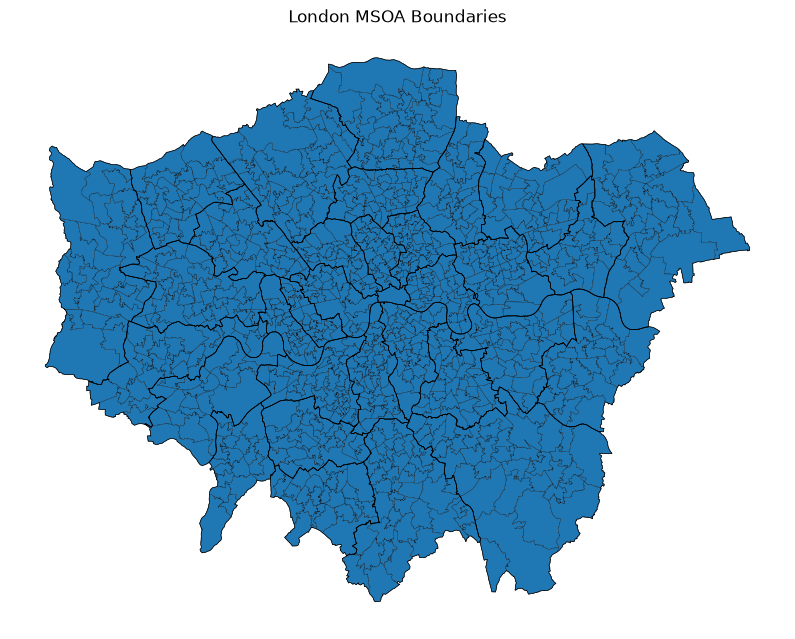

In [10]:
fig, ax = plt.subplots(figsize=(10, 10))

london_msoa.plot(ax=ax, 
                 edgecolor="black",
                 linewidth=0.2)

# Borough boundaries for added context in report
borough_boundaries = london_msoa.dissolve(by="borough_code")

borough_boundaries.boundary.plot(ax=ax,
                                 edgecolor="black",
                                 linewidth=0.5)

plt.title("London MSOA Boundaries")
plt.axis("off")
plt.show()

## Save validated and cleaned MSOA dataset

In [7]:
OUTPUT_PATH = (PROCESSED_SPATIAL_FOLDER/ "london_msoa_2021.gpkg")

london_msoa.to_file(OUTPUT_PATH, driver="GPKG", index=False)

print(f"Saved to: {OUTPUT_PATH}")

Saved to: ..\data\spatial\processed\london_msoa_2021.gpkg
